# Maze Dataset - Fast Suboptimal Pathfinding (Greedy Best-First Search)


In [1]:
import os, numpy as np, pandas as pd, heapq, itertools
from tqdm import tqdm

In [6]:
def load_maze(fp):
    with open(fp) as f: lines = f.readlines()
    return np.array([list(map(int,l.split())) for l in lines if l.strip()])

DIRS = [(0,1),(1,0),(0,-1),(-1,0)]

def gbfs_solve(maze):
    rows,cols = maze.shape
    start,end = (1,0),(rows-2,cols-1)
    
    h = lambda r,c: abs(r-end[0])+abs(c-end[1])
    

    counter = itertools.count()
    heap = [(h(*start), next(counter), start[0], start[1], [start])]
    vis = set()
    
    while heap:
        _, _, r, c, path = heapq.heappop(heap)
        
        if (r,c) == end:
            return path, len(vis)
            
        if (r,c) in vis: continue
        vis.add((r,c))
        
        for dr,dc in DIRS:
            nr,nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in vis:
                heapq.heappush(heap, (h(nr,nc), next(counter), nr, nc, path+[(nr,nc)]))
                
    return None, len(vis)

def count_ops(path):
    if not path or len(path)<2: return None, len(vis)
    ops={'go_straight':0,'turn_left':0,'turn_right':0,'u_turn':0}
    ops['go_straight'] += 1
    for i in range(2, len(path)):
        p=(path[i-1][0]-path[i-2][0],path[i-1][1]-path[i-2][1])
        c=(path[i][0]-path[i-1][0],path[i][1]-path[i-1][1])
        d=(DIRS.index(c)-DIRS.index(p))%4
        if d==0: ops['go_straight']+=1
        elif d==1: ops['turn_right']+=1
        elif d==3: ops['turn_left']+=1
        elif d==2: ops['u_turn']+=1
        return ops

In [3]:
def process(folder, mtype):
    res=[]
    files=sorted([f for f in os.listdir(folder) if f.endswith('.txt')])
    for fn in tqdm(files,desc=mtype):
        dim=int(fn.replace('.txt','').split('_')[1].replace('dim',''))
        maze=load_maze(os.path.join(folder,fn))
        path, explored_count=gbfs_solve(maze)
        ops=count_ops(path)
        res.append({'maze_name':fn.replace('.txt',''),'maze_type':mtype,'dimension':dim,
            'path_length':len(path) if path else 0,
            'total_operations':explored_count,
            'go_straight':ops['go_straight'] if ops else 0,
            'turn_left':ops['turn_left'] if ops else 0,
            'turn_right':ops['turn_right'] if ops else 0,
            'u_turn':ops['u_turn'] if ops else 0})
    return res

r1=process('perfect_maze','perfect')
r2=process('imperfect_maze','imperfect')
df=pd.DataFrame(r1+r2)
dv=df[df['total_operations']>0]
print(f'\nTB tong thao tac (GBFS): {dv["total_operations"].mean():.2f}')
print(f'TB perfect: {dv[dv["maze_type"]=="perfect"]["total_operations"].mean():.2f}')
print(f'TB imperfect: {dv[dv["maze_type"]=="imperfect"]["total_operations"].mean():.2f}')

imperfect: 100%|██████████| 1500/1500 [00:08<00:00, 180.18it/s]


TB tong thao tac (GBFS): 3357.19
TB perfect: 6060.85
TB imperfect: 653.54


In [4]:
ds=df.sort_values(['maze_type','maze_name']).reset_index(drop=True)
do=ds.rename(columns={'maze_name':'Ten Maze','maze_type':'Loai','dimension':'Kich thuoc',
    'path_length':'Do dai duong di','total_operations':'Tong thao tac',
    'go_straight':'Di thang','turn_left':'Re trai','turn_right':'Re phai','u_turn':'Quay dau'})
avg=dv['total_operations'].mean()
with pd.ExcelWriter('maze_operations_result_v2.xlsx',engine='openpyxl') as w:
    do.to_excel(w,sheet_name='All Mazes',index=False)
    do[do['Loai']=='perfect'].to_excel(w,sheet_name='Perfect',index=False)
    do[do['Loai']=='imperfect'].to_excel(w,sheet_name='Imperfect',index=False)
    pd.DataFrame({'Thong ke':['Tong','Perfect','Imperfect','TB tat ca','TB perfect','TB imperfect','Min','Max'],
        'Gia tri':[len(df),len(r1),len(r2),round(avg,2),
        round(dv[dv['maze_type']=='perfect']['total_operations'].mean(),2),
        round(dv[dv['maze_type']=='imperfect']['total_operations'].mean(),2),
        dv['total_operations'].min(),dv['total_operations'].max()]
    }).to_excel(w,sheet_name='Summary',index=False)
print('Xuat: maze_operations_result_v2.xlsx')
do.head(10)

Xuat: maze_operations_result_v2.xlsx


,Ten Maze,Loai,Kich thuoc,Do dai duong di,Tong thao tac,Di thang,Re trai,Re phai,Quay dau
0,maze0_dim52,imperfect,52,295,343,2,0,0,0
1,maze1000_dim83,imperfect,83,465,539,2,0,0,0
2,maze1001_dim28,imperfect,28,187,352,2,0,0,0
3,maze1002_dim141,imperfect,141,1279,1894,1,0,1,0
4,maze1003_dim57,imperfect,57,391,432,2,0,0,0
5,maze1004_dim143,imperfect,143,807,1048,2,0,0,0
6,maze1005_dim43,imperfect,43,263,305,2,0,0,0
7,maze1006_dim106,imperfect,106,773,1131,2,0,0,0
8,maze1007_dim116,imperfect,116,587,693,1,0,1,0
9,maze1008_dim20,imperfect,20,95,116,2,0,0,0


Maze khó nhất: maze560_dim147 (perfect)
Số ô phải duyệt: 31629


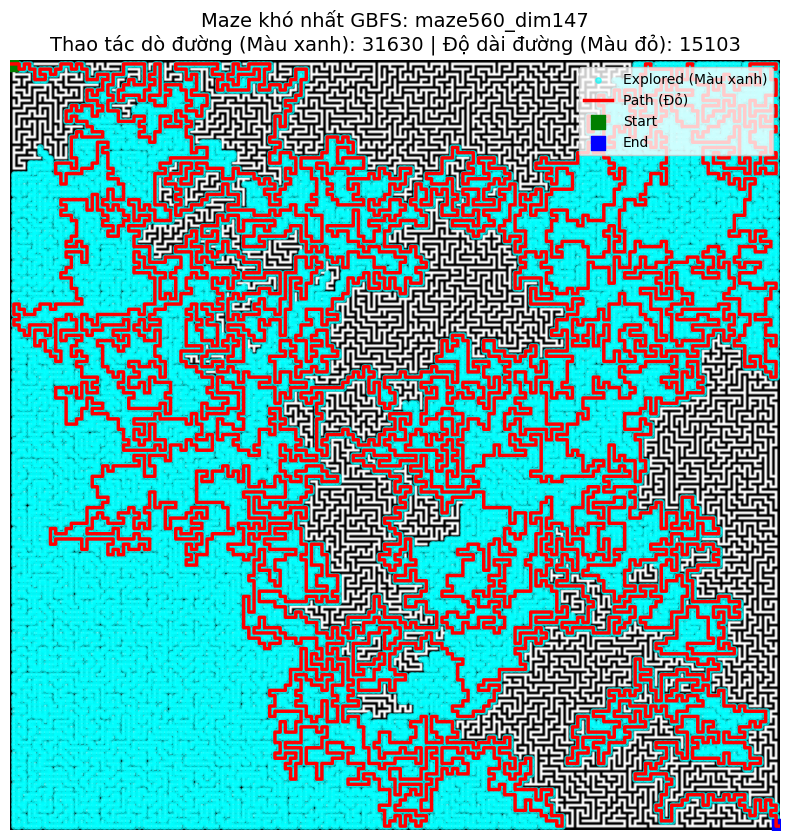

In [ ]:
hardest_maze = dv.loc[dv['total_operations'].idxmax()]
maze_folder = 'perfect_maze' if hardest_maze['maze_type'] == 'perfect' else 'imperfect_maze'
hardest_maze_path = os.path.join(maze_folder, hardest_maze['maze_name'] + '.txt')

print(f"Maze khó nhất: {hardest_maze['maze_name']} ({hardest_maze['maze_type']})")
print(f"Số ô phải duyệt: {hardest_maze['total_operations']}")


maze_hard = load_maze(hardest_maze_path)


def gbfs_demo_viz(maze):
    rows,cols = maze.shape
    start,end = (1,0),(rows-2,cols-1)
    h = lambda r,c: abs(r-end[0])+abs(c-end[1])
    counter = itertools.count()
    heap = [(h(*start), next(counter), start[0], start[1], [start])]
    vis = set()
    visited_order = []
    
    while heap:
        _, _, r, c, path = heapq.heappop(heap)
        if (r,c) == end:
            visited_order.append((r,c))
            return path, visited_order
            
        if (r,c) in vis: continue
        vis.add((r,c))
        visited_order.append((r,c))
        
        for dr,dc in DIRS:
            nr,nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr,nc]==0 and (nr,nc) not in vis:
                heapq.heappush(heap, (h(nr,nc), next(counter), nr, nc, path+[(nr,nc)]))
                
    return None, visited_order

import matplotlib.pyplot as plt

def visualize_maze(maze, path, visited, title="Maze Solution"):
    plt.figure(figsize=(10, 10))
    cmap = plt.cm.binary
    plt.imshow(maze, cmap=cmap)
    
    if visited:
        vis_arr = np.array(visited)
        plt.scatter(vis_arr[:, 1], vis_arr[:, 0], c='cyan', s=15, alpha=0.6, label='Explored (Màu xanh)')
        
    if path:
        path_arr = np.array(path)
        plt.plot(path_arr[:, 1], path_arr[:, 0], c='red', linewidth=2.5, label='Path (Đỏ)')
        
    rows, cols = maze.shape
    start, end = (1, 0), (rows-2, cols-1)
    plt.scatter(start[1], start[0], c='green', s=100, marker='s', label='Start')
    plt.scatter(end[1], end[0], c='blue', s=100, marker='s', label='End')
    
    plt.title(f"{title}\nThao tác dò đường (Màu xanh): {len(visited)} | Độ dài đường (Màu đỏ): {len(path)}", fontsize=14)
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.show()

path_hard, vis_hard = gbfs_demo_viz(maze_hard)
visualize_maze(maze_hard, path_hard, vis_hard, f"Maze khó nhất GBFS: {hardest_maze['maze_name']}")

In [ ]:
avg_path_length = dv['path_length'].mean()
print(f"Trung bình độ dài đường thoát (Đường màu đỏ - STEPS) của 3000 maze: {avg_path_length:.0f}")

Trung bình độ dài đường thoát (Đường màu đỏ - STEPS) của 3000 maze: 2208
